# Modelling

The modelling process follows an iterative workflow, beginning with baseline models to establish initial performance. The best-performing model is then analysed through feature importance, followed by feature refinement and hyperparameter optimisation.

**Steps:**  
→ Feature Engineering (done)  
→ Baseline Models  
→ Feature Importance Analysis  
→ Feature Refinement  
→ Hyperparameter Tuning   
→ Final Model  

**Baseline Models:**
Three baseline ensemble learning algorithms are evaluated:
LightGBM, XGBoost, Random Forest

- Class imbalance is handled by assigning a higher weight to the minority (fraud) class during model training.

**Evaluation Metrics:**  
Since fraudulent transactions represent only a small proportion of the dataset, overall accuracy is not an informative metric. Instead, the models are evaluated using metrics that better reflect performance on imbalanced classification problems.

- AUC-ROC 
- Precision-Recall AUC / PR-AUC (Primary Metric)
- Classification Report

**Note:** Kaggle competition official evaluation metric: ROC-AUC. However, we're using PR-AUC as the primary metric because fraud is rare and precision–recall is more informative under severe class imbalance. PR-AUC balances precision and recall.

## Baseline Models

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

import time
import warnings
warnings.filterwarnings('ignore')

In [5]:
X_train = pd.read_csv('data/X_train_engineered.csv')
X_val = pd.read_csv('data/X_val_engineered.csv')

y_train = pd.read_csv('data/y_train.csv').squeeze()
y_val = pd.read_csv('data/y_val.csv').squeeze()

In [6]:
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train = clean_column_names(X_train)
X_val   = clean_column_names(X_val)

In [7]:
# Note: We are using y_pred = (y_pred_proba >= threshold).astype(int)
# model.predict() internally does exactly this: y_pred = (model.predict_proba(X_val)[:, 1] >= 0.5).astype(int)
# Eg. Model has predicted: y_pred_proba = [0.3, 0.6, 0.1, 0.4, 0.8]
# With threshold 0.5, y_pred = [0, 1, 0, 0, 1]
# Lower threshold -> 0.4 -> y_pred = [0, 1, 0, 1, 1]
# Higher threshold -> 0.7 -> y_pred = [0, 0, 0, 0, 1]

In [8]:
results = []

def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, threshold=0.5):
    # Print the model name
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    # Train
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    print(f"Training time: {train_time:.1f}s")

    # Predict
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    '''
    Note: We are using y_pred = (y_pred_proba >= threshold).astype(int)
    model.predict() internally does exactly this: y_pred = (model.predict_proba(X_val)[:, 1] >= 0.5).astype(int)
    Eg. Model has predicted: y_pred_proba = [0.3, 0.6, 0.1, 0.4, 0.8]
    With threshold 0.5, y_pred = [0, 1, 0, 0, 1]
    Lower threshold -> 0.4 -> y_pred = [0, 1, 0, 1, 1]
    Higher threshold -> 0.7 -> y_pred = [0, 0, 0, 0, 1]
    '''

    # Core metrics
    auc = roc_auc_score(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) \
                if (precision + recall) > 0 else 0

    # Print summary 
    print(f"\n  Core Metrics:")
    print(f"    AUC-ROC:  {auc:.4f}")
    print(f"    PR-AUC:   {pr_auc:.4f}  ← primary metric for imbalanced data")
    print(f"\n  At threshold={threshold}:")
    print(f"    Precision: {precision:.4f}  (of flagged fraud, how many are real)")
    print(f"    Recall:    {recall:.4f}  (of all fraud, how many did we catch)")
    print(f"    F1:        {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:>6,}  FP={fp:>6,}")
    print(f"    FN={fn:>6,}  TP={tp:>6,}")
    print(f"\n  Business interpretation:")
    print(f"    Fraud cases caught:  {tp:,} / {tp+fn:,} ({recall*100:.1f}%)")
    print(f"    False alarms:        {fp:,} ({fp/(tn+fp)*100:.2f}% of legit flagged)")

    # Store results
    metrics = {
        'model':      model_name,
        'auc_roc':    round(auc, 4),
        'pr_auc':     round(pr_auc, 4),
        'precision':  round(precision, 4),
        'recall':     round(recall, 4),
        'f1':         round(f1, 4),
        'tp':         tp, 'fp': fp,
        'tn':         tn, 'fn': fn,
        'train_time': round(train_time, 1),
        'model_obj':  model,
        'y_pred_proba': y_pred_proba
    }
    results.append(metrics)
    return metrics

In [9]:
# Model definitions with class imbalance handling
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Class weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

baseline_models = [
    (
        LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            verbose=-1          # suppress LGBM output
        ),
        "LightGBM"
    ),
    (
        XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            eval_metric='auc',
            verbosity=0
        ),
        "XGBoost"
    ),
    (
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            class_weight='balanced',  # RF uses this instead of scale_pos_weight
            random_state=42,
            n_jobs=-1
        ),
        "Random Forest"
    ),
]

scale_pos_weight: 27.5


In [13]:
# Run all baseline models
for model, model_name in baseline_models:
    evaluate_model(model, model_name, X_train, y_train, X_val, y_val, threshold=0.5)


  LightGBM
Training time: 13.4s

  Core Metrics:
    AUC-ROC:  0.8913
    PR-AUC:   0.5409  ← primary metric for imbalanced data

  At threshold=0.5:
    Precision: 0.3460  (of flagged fraud, how many are real)
    Recall:    0.6321  (of all fraud, how many did we catch)
    F1:        0.4472

  Confusion Matrix:
    TN=109,189  FP= 4,855
    FN= 1,495  TP= 2,569

  Business interpretation:
    Fraud cases caught:  2,569 / 4,064 (63.2%)
    False alarms:        4,855 (4.26% of legit flagged)

  XGBoost
Training time: 25.4s

  Core Metrics:
    AUC-ROC:  0.8879
    PR-AUC:   0.5154  ← primary metric for imbalanced data

  At threshold=0.5:
    Precision: 0.2483  (of flagged fraud, how many are real)
    Recall:    0.6946  (of all fraud, how many did we catch)
    F1:        0.3659

  Confusion Matrix:
    TN=105,499  FP= 8,545
    FN= 1,241  TP= 2,823

  Business interpretation:
    Fraud cases caught:  2,823 / 4,064 (69.5%)
    False alarms:        8,545 (7.49% of legit flagged)

  Ra

In [14]:
# Comparison table
results_df = pd.DataFrame([
    {k: v for k, v in r.items() 
     if k not in ['model_obj', 'y_pred_proba']}
    for r in results
])

print("\n" + "="*60)
print("  BASELINE MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))


  BASELINE MODEL COMPARISON
        model  auc_roc  pr_auc  precision  recall     f1   tp   fp     tn   fn  train_time
     LightGBM   0.8913  0.5409     0.3460  0.6321 0.4472 2569 4855 109189 1495        13.4
      XGBoost   0.8879  0.5154     0.2483  0.6946 0.3659 2823 8545 105499 1241        25.4
Random Forest   0.8921  0.4651     0.2960  0.5903 0.3942 2399 5707 108337 1665        34.0


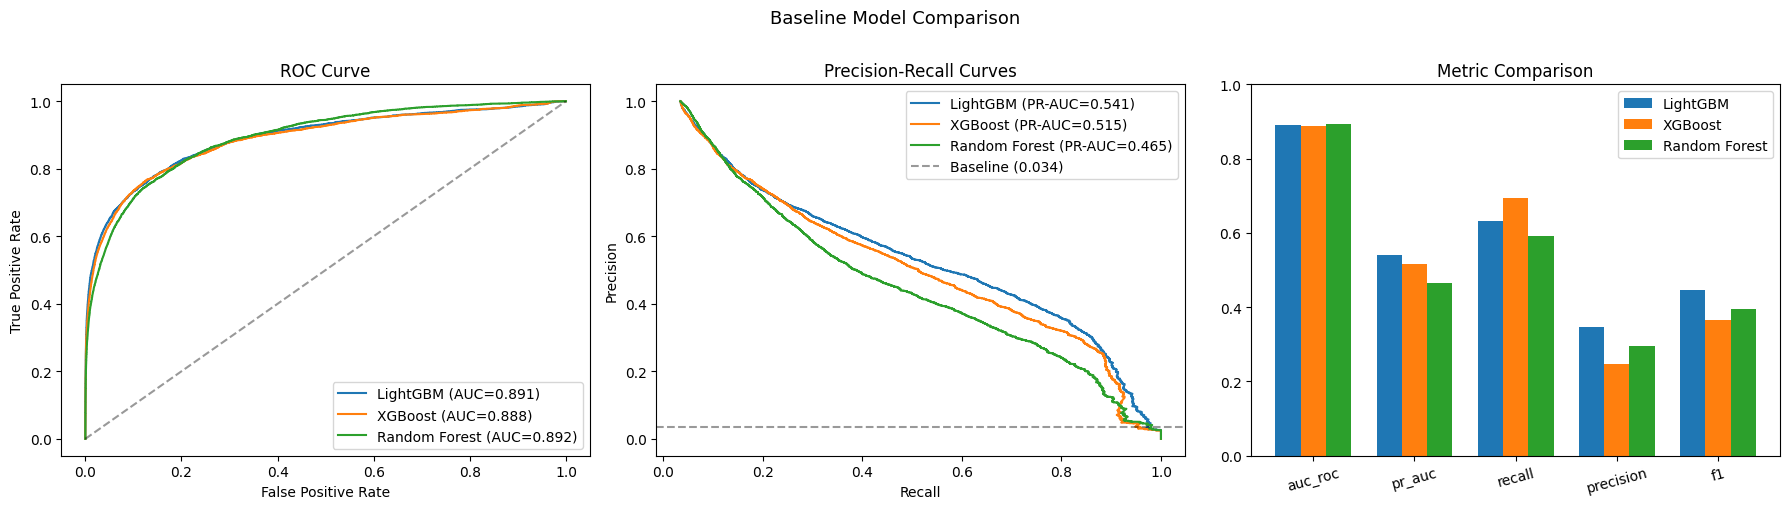

In [17]:
# Visual Comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curves
ax = axes[0]

for r in results:
    fpr, tpr, _ = roc_curve(y_val, r['y_pred_proba'])
    ax.plot(fpr, tpr, label=f"{r['model']} (AUC={r['auc_roc']:.3f})")
ax.plot([0,1], [0,1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# 2. Precision-Recall Curves
ax = axes[1]

for r in results:
    prec, rec, _ = precision_recall_curve(y_val, r['y_pred_proba'])
    ax.plot(prec, rec, label=f"{r['model']} (PR-AUC={r['pr_auc']:.3f})")
ax.axhline(y_val.mean(), color='k', linestyle='--', alpha=0.4, label=f'Baseline ({y_val.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()

# 3. Metric Comparison Bar Chart
ax = axes[2]
metrics_to_plot = ['auc_roc', 'pr_auc', 'recall', 'precision', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, r in enumerate(results):
    values = [r[m] for m in metrics_to_plot]
    ax.bar(x + i*width, values, width, label=r['model'])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1)
ax.set_title('Metric Comparison')
ax.legend()

plt.suptitle('Baseline Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

- The Kaggle metric, AUC-ROC is similar for all 3 models. 
- Next, in terms of PR-AUC (our primary metric), LightGBM performed the best among all three.
- In terms of precision and f1 as well, LightGBM performs the best.
- Note that XGBoost has the highest recall, which means it is detecting the fraudulent transactions more effectively than the other models i.e. the false negatives are the lowest here. However, if we look the false positives, it has ~4K more false positives as compared to LightGBM.
- PR-AUC balances the false negatives v/s false positives.

**Final baseline model selected - LightGBM.**

## Feature Importance

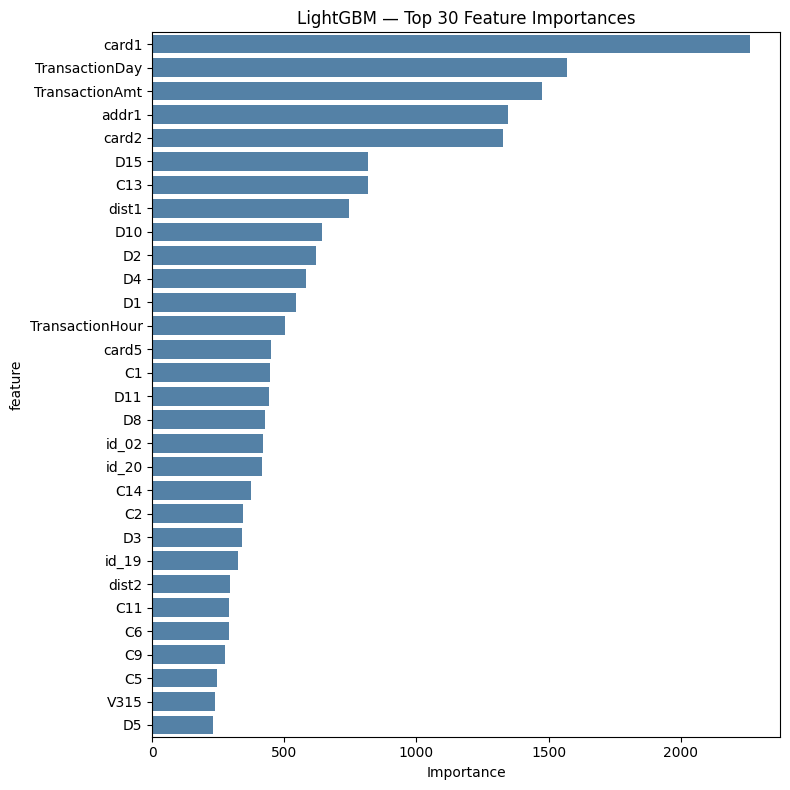


Zero importance features: 79
['id_35_F', 'id_35_Missing', 'id_35_T', 'id_36_Missing', 'id_37_Missing', 'id_38_Missing', 'id_27_Missing', 'id_27_NotFound', 'id_28_Found', 'id_28_Missing', 'id_29_Found', 'id_29_Missing', 'id_29_NotFound', 'id_32_0_0', 'id_32_16_0', 'id_32_Missing', 'id_34_Missing', 'id_34_match_status__1', 'DeviceInfo_Linux', 'V107', 'V110', 'V111', 'V117', 'V118', 'V89', 'id_11_is_missing', 'card6_Missing', 'card6_charge_card', 'card6_debit_or_credit', 'DeviceType_Missing', 'R_emaildomain_Foreign', 'M1_F', 'M1_T', 'M2_Missing', 'M3_Missing', 'D12_is_missing', 'D13_is_missing', 'D14_is_missing', 'D15_is_missing', 'dist1_is_missing', 'dist2_is_missing', 'id_01_is_missing', 'id_02_is_missing', 'id_03_is_missing', 'id_04_is_missing', 'id_05_is_missing', 'id_06_is_missing', 'id_07_is_missing', 'id_08_is_missing', 'id_09_is_missing', 'id_10_is_missing', 'V41', 'M9_Missing', 'D2_is_missing', 'D3_is_missing', 'D6_is_missing', 'D7_is_missing', 'D8_is_missing', 'D9_is_missing', 

In [36]:
# Feature importance (LightGBM)
lgbm_result = next(r for r in results if r['model'] == 'LightGBM')
lgbm_model  = lgbm_result['model_obj']

importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 30
top30 = importance_df.head(30)

plt.figure(figsize=(8, 8))
sns.barplot(data=top30, x='importance', y='feature', color='steelblue')
plt.title('LightGBM — Top 30 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Zero importance features
zero_imp_features = importance_df[importance_df['importance'] == 0]['feature'].tolist()
print(f"\nZero importance features: {len(zero_imp_features)}")
print(zero_imp_features)

- Note that most of the zero importance features are the Missing indicators we created, they were not very informative during evaluation.
- We can drop these zero importance features and train the model again to check how it affects the scores.

In [37]:
# Dropping zero importance features from both train and val
X_train_refined = X_train.drop(columns=zero_imp_features)
X_val_refined   = X_val.drop(columns=zero_imp_features)

print(f"X_train_refined: {X_train_refined.shape}")
print(f"X_val_refined:   {X_val_refined.shape}")

X_train_refined: (472432, 311)
X_val_refined:   (118108, 311)


In [38]:
# Retrain LightGBM on refined features
lgbm_refined = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

evaluate_model(
    lgbm_refined, 'LightGBM (refined)',
    X_train_refined, y_train,
    X_val_refined, y_val,
    threshold=0.5
)


  LightGBM (refined)
Training time: 13.5s

  Core Metrics:
    AUC-ROC:  0.8927
    PR-AUC:   0.5388  ← primary metric for imbalanced data

  At threshold=0.5:
    Precision: 0.3325  (of flagged fraud, how many are real)
    Recall:    0.6422  (of all fraud, how many did we catch)
    F1:        0.4381

  Confusion Matrix:
    TN=108,804  FP= 5,240
    FN= 1,454  TP= 2,610

  Business interpretation:
    Fraud cases caught:  2,610 / 4,064 (64.2%)
    False alarms:        5,240 (4.59% of legit flagged)


{'model': 'LightGBM (refined)',
 'auc_roc': 0.8927,
 'pr_auc': 0.5388,
 'precision': np.float64(0.3325),
 'recall': np.float64(0.6422),
 'f1': np.float64(0.4381),
 'tp': np.int64(2610),
 'fp': np.int64(5240),
 'tn': np.int64(108804),
 'fn': np.int64(1454),
 'train_time': 13.5,
 'model_obj': LGBMClassifier(learning_rate=0.05, n_estimators=500, n_jobs=-1, num_leaves=63,
                random_state=42, scale_pos_weight=np.float64(27.46147358274595),
                verbose=-1),
 'y_pred_proba': array([5.02259870e-03, 2.78561268e-02, 5.47714676e-03, ...,
        1.34450959e-02, 1.29653748e-05, 2.49962290e-01], shape=(118108,))}

In [39]:
# Compare before and after
comparison = pd.DataFrame([
    {k: v for k, v in r.items() 
     if k not in ['model_obj', 'y_pred_proba']}
    for r in results 
    if r['model'] in ['LightGBM', 'LightGBM (refined)']
])
print(comparison.to_string(index=False))

             model  auc_roc  pr_auc  precision  recall     f1   tp   fp     tn   fn  train_time
          LightGBM   0.8913  0.5409     0.3460  0.6321 0.4472 2569 4855 109189 1495        13.4
LightGBM (refined)   0.8927  0.5388     0.3325  0.6422 0.4381 2610 5240 108804 1454        13.5


- AUC-ROC increased slightly, PR-AUC dropped slightly - no meaningul changes.
- Dropping the 79 features did not improve performance or decrease it, so they truely did not contribute to the metrics in any way.
- Note that FP increased from 4855 to 5240 and FN decreased from 1495 to 1454. The model is catching more frauds but also giving more false alarms. It is a small trade-off, acceptable.

Next, we can move on to threshold analysis. We need to check if there is an optimal threshold which gives us the best performance in terms of our selected metrics.

## Optimal Threshold 

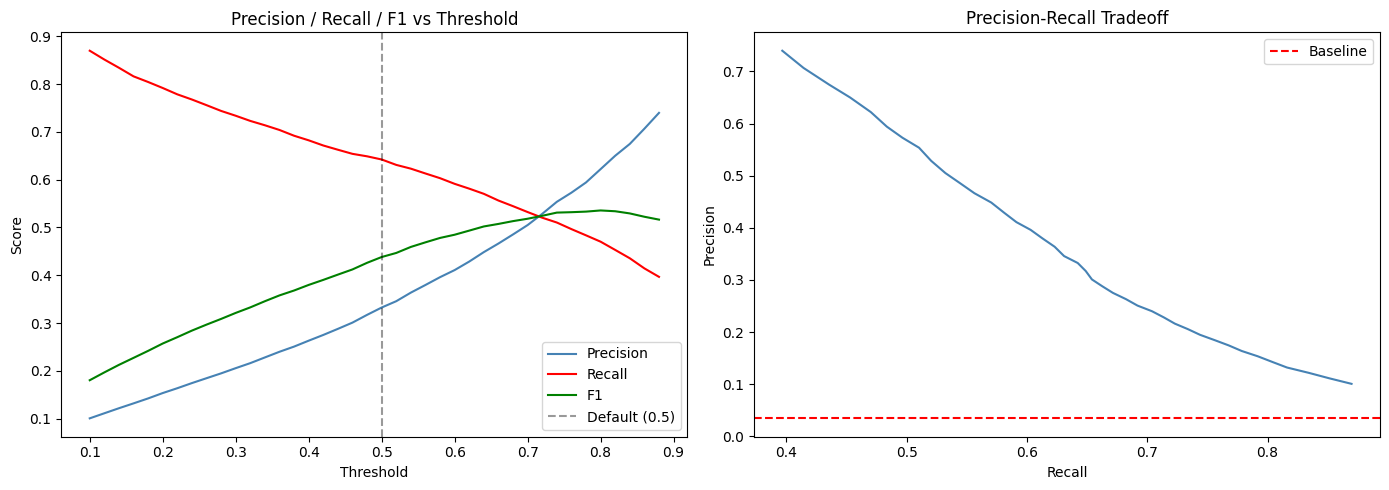

Best F1 threshold: 0.80
At this threshold — Precision: 0.622, Recall: 0.470, F1: 0.536


In [40]:
# Threshold sweep
lgbm_proba = lgbm_refined.predict_proba(X_val_refined)[:, 1]

thresholds  = np.arange(0.1, 0.9, 0.02)
precisions  = []
recalls     = []
f1s         = []

for t in thresholds:
    y_pred = (lgbm_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision', color='steelblue')
axes[0].plot(thresholds, recalls, label='Recall', color='red')
axes[0].plot(thresholds, f1s, label='F1', color='green')
axes[0].axvline(0.5, color='black', linestyle='--', alpha=0.4, label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend()

axes[1].plot(recalls, precisions, color='steelblue')
axes[1].axhline(y_val.mean(), color='red', linestyle='--', label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Tradeoff')
axes[1].legend()

plt.tight_layout()
plt.show()

# Best F1 threshold
best_idx = np.argmax(f1s)
print(f"Best F1 threshold: {thresholds[best_idx]:.2f}")
print(f"At this threshold — Precision: {precisions[best_idx]:.3f}, "
      f"Recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")

- As threshold increases → precision rises (FP decreased), recall falls (FN increased).
- F1 (which balances both) peaks around 0.70–0.75.
- The code found the best F1 at threshold=0.8, of 0.536, but looking at the graph the F1 (green) plateaus around threshold 0.65 to 0.80.

- The Precision-Recall curve is well above the baseline, showing us the model is not completely random.

Threshold 0.3: Recall=~80%, Precision=~20%  
→ Catch 80% of fraud, but 80% of flags are false alarms  
→ Right if fraud cost is very high, investigation team is large  

Threshold 0.5: Recall=64%, Precision=33%  
→ Current default  

Threshold 0.7: Recall=~52%, Precision=~52%  
→ Precision = Recall, balanced  
→ Right if false alarm cost ≈ missed fraud cost  

Threshold 0.8: Recall=47%, Precision=62%  
→ High confidence flags only  
→ Right if investigation capacity is limited  

For our project, we're going to stick to threshold=0.5 (standard baseline). In a production pipeline, the threshold would be set based on business requirements.

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':      [500, 1000, 1500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [31, 63, 127],
    'max_depth':         [-1, 6, 8, 10],
    'min_child_samples': [20, 50, 100],    # min samples per leaf — controls overfitting
    'subsample':         [0.7, 0.8, 1.0], # row sampling per tree
    'colsample_bytree':  [0.7, 0.8, 1.0], # feature sampling per tree
    'reg_alpha':         [0, 0.1, 0.5],   # L1 regularisation
    'reg_lambda':        [0, 0.1, 1.0],   # L2 regularisation
}

lgbm_tuned = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

search = RandomizedSearchCV(
    lgbm_tuned,
    param_distributions=param_grid,
    n_iter=30,              # try 30 random combinations
    scoring='average_precision',  # optimise for PR-AUC
    cv=3,                   # 3-fold CV
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_refined, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV PR-AUC: {search.best_score_:.4f}")

# Evaluate best model on val
evaluate_model(
    search.best_estimator_, 'LightGBM (tuned)',
    X_train_refined, y_train,
    X_val_refined, y_val,
    threshold=0.5
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
